In [52]:
import pandas as pd
import numpy as np

# import california data from sklearn
from sklearn.datasets import fetch_california_housing

# get the data
housing = fetch_california_housing()
print(type(housing))
housing.keys()

<class 'sklearn.utils._bunch.Bunch'>


dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

## Convert into DataFrame

In [53]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# add the target means what we have to predict
df["Price"] = housing.target

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [54]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [55]:
df.shape

(20640, 9)

In [56]:
df.columns.to_list()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'Price']

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [58]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Quick Data Check

In [59]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
Price,float64


In [60]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


## Simple Visualization

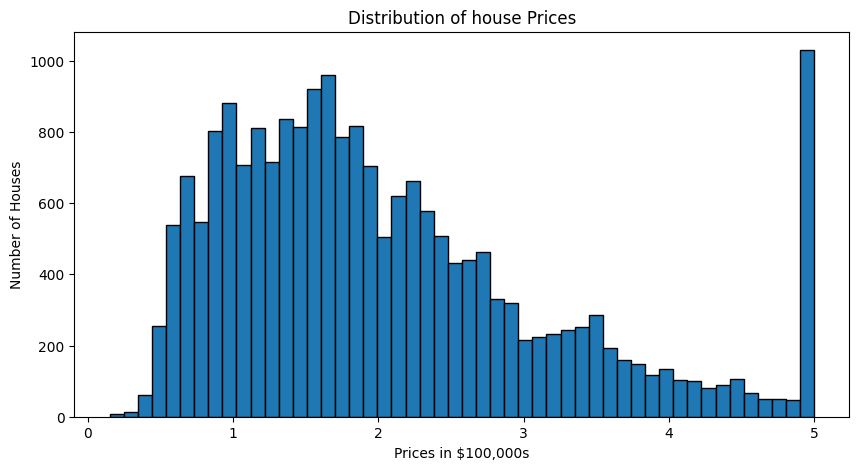

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
plt.hist(df["Price"], bins=50, edgecolor="black")
plt.xlabel("Prices in $100,000s")
plt.ylabel("Number of Houses")
plt.title("Distribution of house Prices")
plt.show()

In [62]:
# coorilation with price
coorelation_with_price = df.corr()["Price"].sort_values(ascending=False)
coorelation_with_price

,Price
Price,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


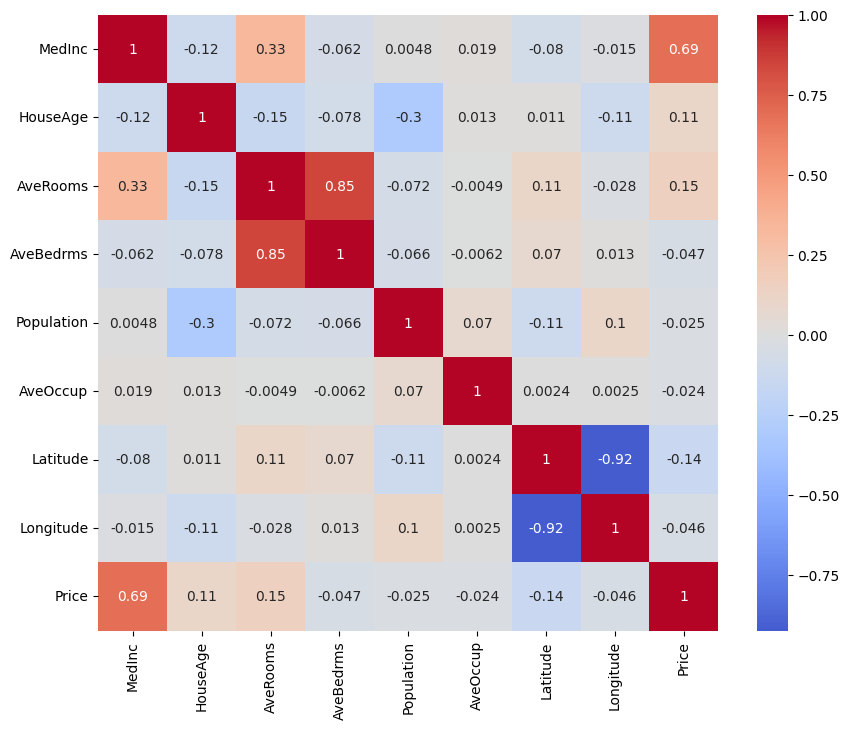

In [63]:
# visualization with coorelation 
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

## Build Model

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop("Price", axis=1)
Y = df["Price"]


# Split data for training and testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# X_train.shape
# X_test.shape

model = LinearRegression()

model.fit(X_train, Y_train)

predictions = model.predict(X_test)


# Evaluate
mse = mean_squared_error(Y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, predictions)

# Model Performance
print(f"Model Performance :")
print(f"RSME: {rmse*100000:.2f}")
print(f"R² Score: {r2:.3f}")
print(f"(R² of 1.0 would be perfect predictions)")


Model Performance :
RSME: 74558.14
R² Score: 0.576
(R² of 1.0 would be perfect predictions)


In [71]:
# Import scaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Note: NOT fit_transform!

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Let's see the difference
print("Before scaling (first row):")
print(X_train.iloc[0])
print("\nAfter scaling (first row):")
print(X_train_scaled.iloc[0])

# Train model with scaled data
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, Y_train)

# Predict and evaluate
predictions_scaled = model_scaled.predict(X_test_scaled)
r2_scaled = r2_score(Y_train, predictions_scaled)
rmse_scaled = np.sqrt(mean_squared_error(Y_train, predictions_scaled))

print(f"\n📊 Scaled Model Performance:")
print(f"R² Score: {r2_scaled:.3f}")
print(f"RMSE: ${rmse_scaled*100000:.2f}")
print(f"Improvement: {(r2_scaled - r2)*100:.1f}% better R²")

Before scaling (first row):
MedInc           3.259600
HouseAge        33.000000
AveRooms         5.017657
AveBedrms        1.006421
Population    2300.000000
AveOccup         3.691814
Latitude        32.710000
Longitude     -117.030000
Name: 14196, dtype: float64

After scaling (first row):
MedInc       -0.326196
HouseAge      0.348490
AveRooms     -0.174916
AveBedrms    -0.208365
Population    0.768276
AveOccup      0.051376
Latitude     -1.372811
Longitude     1.272587
Name: 0, dtype: float64


ValueError: Found input variables with inconsistent numbers of samples: [16512, 4128]